<a href="https://colab.research.google.com/github/ittus/learning-pytorch/blob/main/simple_NeuralNetwork.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [67]:
import torch
import torch.nn as nn
import torch.nn.functional as F


In [68]:
# Create a Model class that inherits nn.Module

class Model(nn.Module):
  # Input layer (4 features of the flower)
  # -> Hidden Layer 1 (number of neurons)
  # -> H2(n)
  # -> output (3 classes of Iris flower)
  def __init__(self, in_features=4, h1=8, h2=9, out_features=3):
    super().__init__()
    self.fc1 = nn.Linear(in_features, h1)
    self.fc2 = nn.Linear(h1, h2)
    self.out = nn.Linear(h2, out_features)

  def forward(self, x):
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = self.out(x)

    return x

In [69]:
torch.manual_seed(41)
model = Model()

In [70]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [71]:
url = 'https://gist.githubusercontent.com/netj/8836201/raw/6f9306ad21398ea43cba4f7d537619d0e07d5ae3/iris.csv'
my_df = pd.read_csv(url)

In [72]:
my_df.head()

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [73]:
# Change last column from string to integers
my_df['variety'] = my_df['variety'].replace('Setosa', 0.0)
my_df['variety'] = my_df['variety'].replace('Versicolor', 1.0)
my_df['variety'] = my_df['variety'].replace('Virginica', 2.0)

my_df

/tmp/ipykernel_703/2585933588.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  my_df['variety'] = my_df['variety'].replace('Virginica', 2.0)


,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2.0
146,6.3,2.5,5.0,1.9,2.0
147,6.5,3.0,5.2,2.0,2.0
148,6.2,3.4,5.4,2.3,2.0


In [74]:
# Train test split
X = my_df.drop('variety', axis=1)
y = my_df['variety']

In [75]:
# Convert to numpy arrays
X = X.values
y = y.values

In [76]:
from sklearn.model_selection import train_test_split

In [77]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=41)

In [78]:
# Convert X fefatures to float tensors
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)

In [79]:
# Conert y labels to tensors long
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

In [80]:
# Set the criterion of the model to measure the error
criterion = nn.CrossEntropyLoss()

# Choose Adam Optimizer, learning rate (if error doesn't go down after a bunch of iteration - epochs, lower learning rate)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [81]:
# Train the model
# Epochs (1 run thr all training data in our network)
epochs = 200
losses = []
for i in range(epochs):
  # Go forwards and get a prediction
  y_pred = model.forward(X_train) # Get predicted results

  # Measure the loss/error
  loss = criterion(y_pred, y_train) # predicted values vs the y_train

  # Keep track of losses
  losses.append(loss.detach().numpy())

  # print every 10 epoch
  if i % 10 == 0:
    print(f'Epoch: {i} and loss: {loss}')

  # Do back propagation: take the error rate of forward propagation
  # feed it back thr the network to fine tune the weights
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()




Epoch: 0 and loss: 1.125203251838684
Epoch: 10 and loss: 1.0097211599349976
Epoch: 20 and loss: 0.8162347674369812
Epoch: 30 and loss: 0.585993230342865
Epoch: 40 and loss: 0.4003389775753021
Epoch: 50 and loss: 0.26794716715812683
Epoch: 60 and loss: 0.1796349585056305
Epoch: 70 and loss: 0.12165623158216476
Epoch: 80 and loss: 0.0860651507973671
Epoch: 90 and loss: 0.06522614508867264
Epoch: 100 and loss: 0.05286872014403343
Epoch: 110 and loss: 0.04508011043071747
Epoch: 120 and loss: 0.03979310765862465
Epoch: 130 and loss: 0.03596426919102669
Epoch: 140 and loss: 0.03302799537777901
Epoch: 150 and loss: 0.030512524768710136
Epoch: 160 and loss: 0.02773350290954113
Epoch: 170 and loss: 0.024612102657556534
Epoch: 180 and loss: 0.02167237363755703
Epoch: 190 and loss: 0.01932021789252758


Text(0.5, 0, 'Epoch')

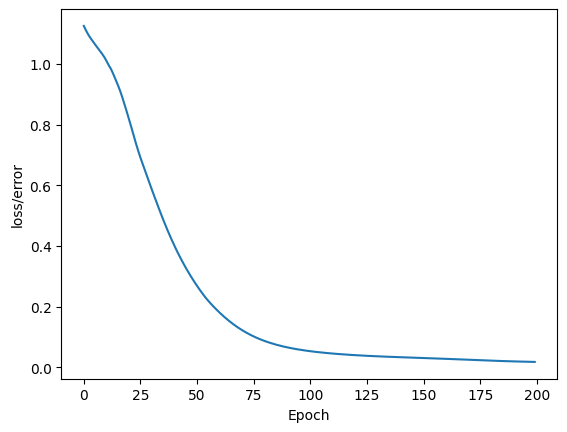

In [82]:
# Graph it out!
plt.plot(range(epochs), losses)
plt.ylabel("loss/error")
plt.xlabel("Epoch")